# Read Gage Output with Python Readers

using `read_gage.python.output_readers`

In [9]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt

# Resolve repo root from current working directory
cwd = Path.cwd().resolve()
repo_root = cwd if (cwd / "read_gage").is_dir() else cwd.parent

if not (repo_root / "read_gage").is_dir():
    raise RuntimeError(
        f"Could not find read_gage package from cwd={cwd}. "
        "Open the notebook from the gage_python workspace or select the correct kernel."
    )

# Ensure local package is importable without pip install -e .
sys.path.insert(0, str(repo_root))

from read_gage.python import read_aline_output

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True

## Read A-line (if hydrophone IS NOT defined during the acquisition)

In [10]:
aline_file = repo_root / 'examples' / 'example_data' / 'aline_20260401_hydrophone_not_defined.txt'
cal_file = repo_root / 'read_gage' / 'calibrations' / 'h1393_p1322_rightangle_highgain.txt'

aline = read_aline_output(aline_file, calibration_file_path=cal_file)
time_us = aline['time_axis_us']
voltage_v = aline['voltage_data_v']
pressure_pa = aline['pressure_data_pa']

print(f'Loaded: {aline_file.name}')
print(f'Time samples: {time_us.size}')
print(f'A-lines: {voltage_v.shape[1]}')
print(f'Pressure available: {pressure_pa is not None}')

Loaded: aline_20260401_hydrophone_not_defined.txt
Time samples: 20096
A-lines: 10
Pressure available: True


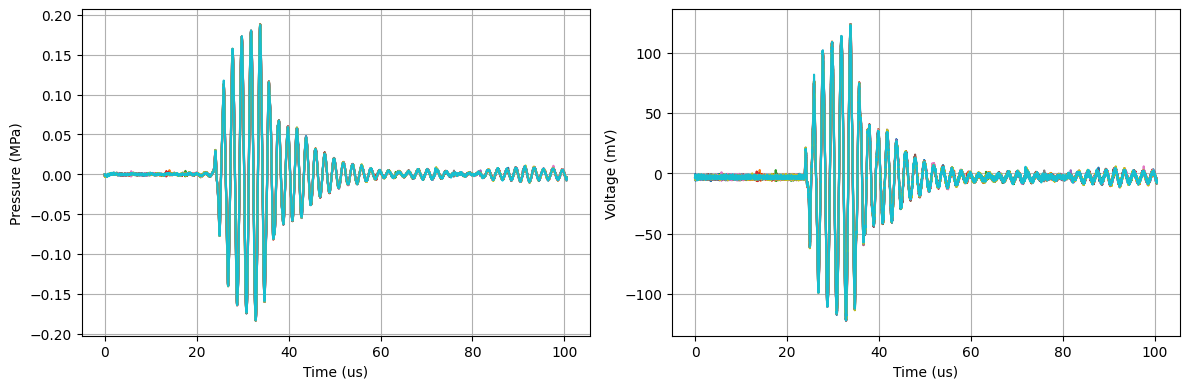

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

if pressure_pa is not None:
    axes[0].plot(time_us, pressure_pa * 1e-6)
    axes[0].set_ylabel('Pressure (MPa)')
else:
    axes[0].text(0.5, 0.5, 'No pressure data (missing calibration).', ha='center', va='center', transform=axes[0].transAxes)
    axes[0].set_ylabel('Pressure (MPa)')

axes[0].set_xlabel('Time (us)')

axes[1].plot(time_us, voltage_v * 1e3)
axes[1].set_xlabel('Time (us)')
axes[1].set_ylabel('Voltage (mV)')

plt.tight_layout()
plt.show()

## Read A-line (if hydrophone IS defined during the acquisition)

TODO: add an example data file with hydrophone defined in acquisition parameters.

## Read M-mode

TODO: add an M-mode example file and call `read_mmode_output(path)`.

## Read beammap - 2D

TODO: add a 2D Beammap example folder and call `read_beammap_output(path)`.

## Read beammap - 2D

TODO: add a 3D Beammap example folder and call `read_beammap_output(path)`.